# Information Capacity Signals in Linear-Recurrent LMs

**Research question.** For a fixed-size recurrent sequence model, *which information-theoretic
signal best reflects the information capacity demanded by the input data?*

We lay the study out as a **2-axis matrix**: `signal (Axis 1) × dataset (Axis 2)`, evaluated on
**two architectures** with a fixed-size recurrent state.

### Axis 1 — Signals (information-theoretic)
| id | Signal | What it captures |
|----|--------|------------------|
| **S1** | **Effective rank (eRank)** of the recurrent state | `exp(spectral entropy)` of the state's singular values → how many state directions are in use. |
| **S2** | **Predictive entropy / bits-per-token** | Shannon entropy of the next-token distribution + how fast in-context surprisal drops. |
| **S3** | **In-context epiplexity** | Area under the per-token NLL curve *above its asymptote* — the learnable structure the model extracts from the input (prequential code length, run in-context on the frozen model). arXiv:2601.03220. |
| **S4** | **Recall / decodable capacity** | For MQAR: effective bits stored vs. *known* ground-truth. Generally: how much of the input is linearly decodable from the state (linear probe). |

### Axis 2 — Data
| id | Dataset | Why |
|----|---------|-----|
| **D1** | **MQAR** (multi-query associative recall) | Synthetic k-v recall; ground-truth information content is *known* (`N·log2 |V|` bits) → **calibration anchor**. |
| **D2** | **Natural language** (WikiText / Pile) | Real, redundant, compressible data. |
| **D3** | **State-tracking** (A5/S5 word problems, parity, flip-flop) | Info must be *maintained* as evolving state. arXiv:2404.08819. |

### Models (fixed-size recurrent state)
- **`state-spaces/mamba2-370m`** — Mamba-2 SSD; state `(nheads, headdim, d_state)` per layer.
- **`linear-moe-hub/MoM-Gated-Deltanet-340M`** — Gated DeltaNet (flash-linear-attention); matrix-valued recurrent state per head.

> **Scope (v1):** All four signals (S1–S4) and all three datasets (D1–D3) are implemented, and both
> models load on the Blackwell GPU (GDN via a weight adapter — see §2b). §5 is the S1-eRank-vs-MQAR-load
> worked example (both models); §6 runs the full `signal × dataset × model` matrix. Still **TODO** (§7):
> the S4 linear probe (decodable bits) and the analysis pass — chiefly whether S3 (epiplexity) separates
> D1/D2/D3 as hypothesized, plus multi-seed calibration against MQAR ground-truth bits.


## 0. Setup

Run in a CUDA environment. Uncomment to install.

In [1]:
# !pip install torch transformers datasets
# !pip install mamba-ssm causal-conv1d          # for state-spaces/mamba2-370m
# !pip install flash-linear-attention            # for the Gated-DeltaNet model (fla)
# !pip install matplotlib seaborn scipy scikit-learn tqdm

## 1. Imports & config

In [2]:
import os, sys, math, json, warnings
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Reuse the repo's helpers (effective_rank, get_ssm_states, ...) from mamba3_analysis/utils.py
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))   # notebooks/ -> repo root
sys.path.insert(0, os.path.join(REPO_ROOT, "mamba3_analysis"))
try:
    import utils as repo_utils          # effective_rank, get_ssm_states, get_A_disc, ...
    print("Imported repo utils:", [f for f in dir(repo_utils) if not f.startswith("_")][:8])
except Exception as e:
    repo_utils = None
    print("repo utils not importable (fine, we redefine what we need):", e)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("Device:", DEVICE)

✓ All utility functions defined successfully!
Imported repo utils: ['AutoTokenizer', 'InferenceParams', 'MambaLMHeadModel', 'TSNE', 'check_keywords', 'classify_heads', 'clear_memory', 'compute_state_cosine']
Device: cuda


In [3]:
# Central registries -------------------------------------------------------
MODELS = {
    "mamba2-370m": {"hf": "state-spaces/mamba2-370m", "kind": "mamba2"},
    "gdn-340m":    {"hf": "linear-moe-hub/MoM-Gated-Deltanet-340M", "kind": "gdn"},
}
SIGNALS  = ["S1_erank", "S2_pred_entropy", "S3_epiplexity", "S4_recall_capacity"]
DATASETS = ["D1_mqar", "D2_natural_language", "D3_state_tracking"]
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd(),
                           "notebooks", "capacity_results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)

results -> /home/sohyung/SSM_Rank_Analysis/notebooks/capacity_results


## 2. Model loading & unified state interface

Each backend exposes the same interface via a `ModelBundle`:
- `bundle.logits(input_ids)` -> `(B, T, V)` logits (for S2 / S3)
- `bundle.states(input_ids)` -> `{layer_idx: state_tensor}` final recurrent state (for S1 / S4)


In [4]:
class ModelBundle:
    def __init__(self, name, model, tokenizer, kind):
        self.name, self.model, self.tokenizer, self.kind = name, model, tokenizer, kind

    @torch.no_grad()
    def logits(self, input_ids):
        input_ids = input_ids.to(DEVICE)
        out = self.model(input_ids)
        return out.logits if hasattr(out, "logits") else out[0]

    @torch.no_grad()
    def states(self, input_ids):
        input_ids = input_ids.to(DEVICE)
        if self.kind == "mamba2":
            return _mamba2_states(self.model, input_ids)
        elif self.kind == "gdn":
            return _gdn_states(self.model, input_ids)   # TODO: verify against installed fla
        raise ValueError(self.kind)


def load_bundle(name):
    spec = MODELS[name]
    if spec["kind"] == "mamba2":
        from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
        from transformers import AutoTokenizer
        tok = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
        model = MambaLMHeadModel.from_pretrained(spec["hf"], device=DEVICE, dtype=torch.float32)
        model.eval()
        return ModelBundle(name, model, tok, "mamba2")
    elif spec["kind"] == "gdn":
        # The linear-moe-hub MoM checkpoints (early 2025) were trained with a transitional
        # codebase whose arch differs from current fla in exactly two spots: (1) a *fused*
        # SwiGLU MLP (gate_proj = 2*intermediate, no separate up_proj) and (2) an attn.D
        # skip term. Everything else (attention, conv, A_log, memory routing, norms,
        # embeddings) matches current fla's MomForCausalLM. So we load current fla and
        # adapt the weights: split the fused gate_proj -> gate_proj + up_proj (gate half
        # first -- validated by LM loss 3.11 vs 14.05 for the reversed split) and drop D
        # (it is an output skip, so it never enters the recurrent state we measure). This
        # keeps everything in one Blackwell-ready env instead of an unavailable old fla.
        import fla  # noqa: F401
        from safetensors.torch import load_file
        from huggingface_hub import hf_hub_download
        from transformers import AutoTokenizer
        from fla.models.mom import MomConfig, MomForCausalLM
        MomForCausalLM._tied_weights_keys = {}          # transformers>=5 wants dict/None
        cfg = MomConfig.from_pretrained(spec["hf"])
        ckpt = load_file(hf_hub_download(spec["hf"], "model.safetensors"))
        sd = {}
        for k, v in ckpt.items():
            if k.endswith("attn.D"):
                continue                                # output skip; not in current arch
            if k.endswith("mlp.gate_proj.weight") and v.shape[0] % 2 == 0:
                half = v.shape[0] // 2
                sd[k] = v[:half]                                    # gate half
                sd[k.replace("gate_proj", "up_proj")] = v[half:]    # up half
            else:
                sd[k] = v
        model = MomForCausalLM(cfg)
        missing = [k for k in model.load_state_dict(sd, strict=False).missing_keys
                   if not k.endswith("attn.D")]
        assert not missing, f"unexpected missing keys after adapt: {missing[:6]}"
        tok = AutoTokenizer.from_pretrained(spec["hf"])
        model = model.to(DEVICE).eval()
        return ModelBundle(name, model, tok, "gdn")
    raise ValueError(name)

### 2a. State extraction — Mamba-2 (works today)
Uses `InferenceParams`; final SSM state per layer has shape `(nheads, headdim, d_state)`
(mamba2-370m: `24 × 64 × 128`). Mirrors `mamba3_analysis/utils.get_ssm_states`.

In [5]:
def _mamba2_states(model, input_ids):
    from mamba_ssm.utils.generation import InferenceParams
    if input_ids.dim() == 1:
        input_ids = input_ids.unsqueeze(0)
    ip = InferenceParams(max_seqlen=input_ids.shape[1], max_batch_size=input_ids.shape[0])
    with torch.no_grad():
        _ = model(input_ids, inference_params=ip)
    states = {}
    for layer_idx, (conv_state, ssm_state) in ip.key_value_memory_dict.items():
        # ssm_state: (batch, nheads, headdim, d_state) -> drop batch (assume B=1 here)
        states[layer_idx] = ssm_state[0].detach().cpu().float()
    return states

### 2b. State extraction — MoM Gated-DeltaNet  *(implemented; verify layout on GPU via self-check)*

`config`: `model_type='mom_gated_deltanet'`, 24 layers, `num_heads=4`, `head_dim=256`, `expand_v=1`,
**`num_memories=4`**, `topk=2`.

**Loading note (checkpoint↔library drift).** This checkpoint predates fla's PyPI releases and was
trained with a transitional codebase: its MLP is a *fused* SwiGLU (`gate_proj = 2×intermediate`, no
separate `up_proj`) and it carries an `attn.D` skip term — neither present in current fla. Rather than
chase an unavailable old fla (MoM wasn't even in fla 0.1, and old Triton won't target Blackwell), the
loader adapts the weights onto current fla's `MomForCausalLM`: split the fused `gate_proj` into
`gate_proj`+`up_proj` (gate half first — confirmed by LM loss **3.11** vs **14.05** for the reversed
split) and drop `D` (an output skip that never enters the recurrent state). Every other tensor maps
1:1, so this is a faithful reconstruction of the state dynamics.

MoM keeps a **mixture of memories**, so the cache is *not* a single matrix like Mamba-2. Via the fla
`Cache` API (`transformers>4.53.3` → `FLACache`, else `LegacyFLACache`), `cache[layer]['recurrent_state']`
is a **list** `[primary, (shared?)]`. The primary memory stacks the `num_memories` states along the
batch axis → `(batch·num_memories, num_heads, head_k, head_v)`. The delta-rule recurrent state puts the
matrix in the **last two dims** `(head_k, head_v)`.

Our extractor assumes **batch = 1** (call `states()` on one sequence) and returns, per layer, a stack of
`num_memories · num_heads` matrices of shape `(head_k, head_v)` — so `S1_erank` treats each *memory-head*
as one unit (memory axis flattened in). Run the **self-check cell** below on your GPU box to confirm the
layout for your installed `fla` version before trusting the numbers.

In [6]:
def _gdn_states(model, input_ids):
    """Final recurrent state per layer for MoM Gated-DeltaNet (flash-linear-attention).

    Returns {layer_idx: Tensor(n_matrices, head_k, head_v)} with n_matrices =
    num_memories * num_heads (+ shared memory if present), assuming batch size 1.
    The matrix is taken from the last two dims of whatever tensors the cache holds,
    so this is robust to leading-axis layout (batch / memory / head ordering).
    """
    if input_ids.dim() == 1:
        input_ids = input_ids.unsqueeze(0)
    assert input_ids.shape[0] == 1, "_gdn_states assumes batch size 1"
    with torch.no_grad():
        out = model(input_ids, use_cache=True)
    cache = out.past_key_values
    n_layers = getattr(model.config, "num_hidden_layers", None) or len(cache)
    states = {}
    for i in range(n_layers):
        try:
            rs = cache[i]["recurrent_state"]        # FLACache/LegacyFLACache -> layer state dict
        except Exception:
            continue
        elems = rs if isinstance(rs, (list, tuple)) else [rs]   # MoM: [primary, (shared?)]
        mats = []
        for el in elems:
            if el is None or not torch.is_tensor(el) or el.dim() < 2:
                continue
            t = el.detach().cpu().float()
            mats.append(t.reshape(-1, t.shape[-2], t.shape[-1]))   # (*, head_k, head_v)
        if mats:
            states[i] = torch.cat(mats, dim=0)      # (num_memories*num_heads[+shared], head_k, head_v)
    if not states:
        raise RuntimeError("No recurrent_state found in cache — run the 2b self-check to inspect layout.")
    return states

#### 2b self-check *(safe to run top-to-bottom — skips cleanly if `fla`/GPU/model are unavailable)*
Prints the live cache layout and exercises the extractor, so you can confirm the MoM memory axis is
being flattened as intended.

In [7]:
def gdn_state_selfcheck(seq_len=32):
    _b = load_bundle("gdn-340m")
    cfg = _b.model.config
    print(f"model_type={cfg.model_type} layers={cfg.num_hidden_layers} "
          f"num_heads={getattr(cfg,'num_heads','?')} head_dim={getattr(cfg,'head_dim','?')} "
          f"num_memories={getattr(cfg,'num_memories','?')}")
    _ids = torch.randint(0, 1000, (1, seq_len)).to(DEVICE)
    with torch.no_grad():
        _out = _b.model(_ids, use_cache=True)
    _cache = _out.past_key_values
    print("cache class:", type(_cache).__name__)
    _rs = _cache[0]["recurrent_state"]
    _elems = _rs if isinstance(_rs, (list, tuple)) else [_rs]
    print("layer0 recurrent_state:", type(_rs).__name__,
          "elems ->", [None if e is None else tuple(e.shape) for e in _elems])
    _st = _b.states(_ids)
    print("extractor layer0 ->", tuple(_st[0].shape), "= (num_memories*num_heads, head_k, head_v)")
    return _b

try:
    gdn_state_selfcheck()
except Exception as e:
    print("GDN self-check skipped:", type(e).__name__, "-", str(e)[:140])

[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type `mom`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


model_type=mom_gated_deltanet layers=24 num_heads=4 head_dim=256 num_memories=4


cache class: Cache
layer0 recurrent_state: list elems -> [(4, 4, 256, 256), (1, 4, 256, 256)]
extractor layer0 -> (20, 256, 256) = (num_memories*num_heads, head_k, head_v)


## 3. Axis 1 — Signal implementations

All signals reduce to a single scalar per (sequence, model) so they can populate the matrix.

### S1 · Effective rank of the recurrent state  *(fully implemented — used in the worked example)*
`eRank(M) = exp(H)` where `H` is the Shannon entropy of the normalized singular-value spectrum of `M`.
We compute it per matrix and average. For Mamba-2 each matrix is a head's `(headdim, d_state)`; for MoM
Gated-DeltaNet each matrix is a *memory-head*'s `(head_k, head_v)` (the extractor flattens the
`num_memories × num_heads` axes), so the same code covers both.

In [8]:
def effective_rank(matrix):
    """exp(Shannon entropy of normalized singular values). Matches repo_utils.effective_rank."""
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.cpu().numpy()
    s = np.linalg.svd(matrix, compute_uv=False)
    s = s / (s.sum() + 1e-12)
    return float(np.exp(-np.sum(s * np.log(s + 1e-12))))


def S1_erank(bundle, input_ids):
    """Mean per-head effective rank of the final recurrent state, averaged over layers."""
    states = bundle.states(input_ids)          # {layer: (nheads, headdim, d_state)}
    per_layer = []
    for layer_idx, st in states.items():
        if st.dim() == 2:                       # flat state -> single matrix
            per_layer.append(effective_rank(st))
        else:                                   # (nheads, d1, d2) -> mean over heads
            per_layer.append(np.mean([effective_rank(st[h]) for h in range(st.shape[0])]))
    return {"erank_mean": float(np.mean(per_layer)),
            "erank_per_layer": np.asarray(per_layer)}

### S2 · Predictive entropy / bits-per-token  *(implemented helper)*
Shannon entropy of the next-token distribution (nats), plus mean bits-per-token (NLL of the realized
next token). Low predictive entropy late in a sequence ⇒ the state has absorbed usable structure.

In [9]:
@torch.no_grad()
def S2_pred_entropy(bundle, input_ids):
    if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
    logits = bundle.logits(input_ids)                       # (B,T,V) on model device
    logp = torch.log_softmax(logits.float(), dim=-1)
    p = logp.exp()
    ent = -(p * logp).sum(-1)                               # (B,T) predictive entropy, nats
    # realized bits-per-token: NLL of the true next token
    tgt = input_ids[:, 1:].to(logp.device)
    nll = -logp[:, :-1, :].gather(-1, tgt.unsqueeze(-1)).squeeze(-1)   # (B,T-1) nats
    return {"pred_entropy_mean": float(ent.mean()),
            "bits_per_token": float(nll.mean() / math.log(2)),
            "pred_entropy_curve": ent[0].cpu().numpy()}

### S3 · In-context epiplexity  *(implemented helper)*
Prequential code length run **in-context** on the frozen model: the area under the per-token NLL
curve *above its asymptote*. Let `nll_t = -log p(x_t | x_{<t})` and let `A` = asymptotic loss (mean
NLL over the final fraction of the sequence). Then
`epiplexity ≈ Σ_t max(nll_t − A, 0)` — the extra bits paid early, i.e. the learnable structure the
model extracts as context accumulates (arXiv:2601.03220, prequential estimator).

In [10]:
@torch.no_grad()
def S3_epiplexity(bundle, input_ids, tail_frac=0.2):
    if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
    logits = bundle.logits(input_ids)
    logp = torch.log_softmax(logits.float(), dim=-1)
    tgt = input_ids[:, 1:].to(logp.device)
    nll = -logp[:, :-1, :].gather(-1, tgt.unsqueeze(-1)).squeeze(-1)[0]  # (T-1,) nats
    nll_bits = nll.cpu().numpy() / math.log(2)
    k = max(1, int(len(nll_bits) * tail_frac))
    asymptote = float(nll_bits[-k:].mean())                 # final loss
    excess = np.clip(nll_bits - asymptote, 0, None)
    return {"epiplexity_bits": float(excess.sum()),         # area above final loss (scales with T)
            "epiplexity_per_token": float(excess.mean()),   # length-normalized (cross-dataset fair)
            "asymptote_bits": asymptote,
            "nll_curve_bits": nll_bits}

### S4 · Recall / decodable capacity  **[TODO: linear probe]**
Two flavors: (a) *ground-truth* bits for MQAR = `N · log2|V|` (known); (b) *decodable* bits = how well
a linear probe recovers stored values from the final state. Ground-truth is implemented; the probe is
a TODO next-pass.

In [11]:
def S4_ground_truth_bits(n_pairs, vocab):
    """Known information content of an MQAR instance, in bits."""
    return float(n_pairs * math.log2(vocab))


def S4_recall_capacity(bundle, input_ids, meta=None):
    # TODO(next-pass): fit a linear probe from bundle.states(input_ids) -> stored values,
    #   report decodable bits = accuracy-weighted N*log2|V|. For now return ground truth if known.
    gt = S4_ground_truth_bits(meta["n_pairs"], meta["vocab"]) if meta else None
    return {"ground_truth_bits": gt, "decodable_bits": None}  # decodable_bits: TODO

## 4. Axis 2 — Dataset builders

### D1 · MQAR  *(fully implemented — used in the worked example)*
We build sequences **directly as token ids** (MQAR is synthetic, so we bypass the tokenizer): sample
`N` distinct keys and their values from a reserved id range, interleave `k v k v ...`, then append the
keys again as queries. Increasing `N` increases the true information load `N·log2|V|`.

In [12]:
def make_mqar_batch(n_pairs, vocab=512, key_offset=1000, val_offset=2000,
                    n_seq=8, query_all=True, seed=0):
    """Return (input_ids [n_seq, T], meta). Ids kept well inside the model vocab (~50k)."""
    rng = np.random.default_rng(seed)
    seqs = []
    for _ in range(n_seq):
        keys = rng.choice(vocab, size=n_pairs, replace=False) + key_offset
        vals = rng.choice(vocab, size=n_pairs, replace=True)  + val_offset
        pairs = np.empty(n_pairs * 2, dtype=np.int64)
        pairs[0::2] = keys; pairs[1::2] = vals
        queries = keys if query_all else keys[: max(1, n_pairs // 2)]
        seqs.append(np.concatenate([pairs, queries]))
    T = min(len(s) for s in seqs)
    ids = torch.tensor(np.stack([s[:T] for s in seqs]), dtype=torch.long)
    meta = {"n_pairs": n_pairs, "vocab": vocab, "T": T,
            "gt_bits": S4_ground_truth_bits(n_pairs, vocab)}
    return ids, meta

### D2 · Natural language  *(implemented)*
WikiText-2 (raw) test split, tokenised with **each model's own tokenizer** and chunked into fixed
windows. Real, compressible text — the regime where in-context structure (S3 epiplexity) should be
high. Because tokenizers differ across models, NLL-based signals (S2/S3) are comparable *within* a
model across datasets, not across models.

In [13]:
def make_natural_language_batch(tokenizer, seq_len=256, n_seq=8, split="test",
                                dataset="Salesforce/wikitext", config="wikitext-2-raw-v1", seed=0):
    """Return (input_ids [n_seq, seq_len], meta) from real text via the model's tokenizer."""
    from datasets import load_dataset
    ds = load_dataset(dataset, config, split=split)
    toks = []
    for line in ds["text"]:
        if line.strip():
            toks.extend(tokenizer(line).input_ids)
        if len(toks) >= n_seq * seq_len:
            break
    toks = toks[: n_seq * seq_len]
    ids = torch.tensor(toks, dtype=torch.long).reshape(n_seq, seq_len)
    return ids, {"source": f"{dataset}/{config}", "T": seq_len, "gt_bits": None}

### D3 · State-tracking  *(implemented)*
Instruction/element streams whose meaning is a *running state* the model must maintain:
- **A5** — word problem on the alternating group A₅ (NC¹-complete; the minimal *hard* state-tracking
  benchmark; refs: Merrill et al. *Illusion of State* arXiv:2404.08819, DeltaProduct arXiv:2502.10297).
- **parity** — running XOR of a bit stream (1 bit of state).
- **flipflop** — write/read/ignore over a single register.

Each symbol becomes a distinct reserved token id (like MQAR). We also compute the *ground-truth running
state* and store it in `meta["state_seq"]` + `meta["state_bits"]` — used later for the S4 probe and the
S3-by-dataset analysis (see Section 7). Right now the stream drives the forward pass so S1/S2/S3 are
computable on D3.

In [14]:
import itertools as _it

def _even_perms(n=5):
    def sign(p):
        s = 1
        for i in range(len(p)):
            for j in range(i + 1, len(p)):
                if p[i] > p[j]: s = -s
        return s
    return [p for p in _it.permutations(range(n)) if sign(p) == 1]

_A5 = _even_perms(5)                       # 60 even permutations
def _compose(p, q): return tuple(p[q[i]] for i in range(len(q)))

def make_state_tracking_batch(task="A5", length=128, n_seq=8, base_offset=3000, seed=0):
    """Return (input_ids [n_seq, length], meta) for a state-tracking stream.
    meta carries the ground-truth running state (state_seq) and its bit-width (state_bits)."""
    rng = np.random.default_rng(seed)
    if task == "parity":
        vocab, state_bits = 2, 1.0
        toks = rng.integers(0, vocab, size=(n_seq, length))
        state_seq = np.cumsum(toks, axis=1) % 2
    elif task == "flipflop":
        # 0=write0, 1=write1, 2=read (read/ignore keep the register)
        vocab, state_bits = 3, 1.0
        toks = rng.integers(0, vocab, size=(n_seq, length))
        state_seq = np.zeros_like(toks)
        for r in range(n_seq):
            cur = 0
            for t in range(length):
                if toks[r, t] == 0: cur = 0
                elif toks[r, t] == 1: cur = 1
                state_seq[r, t] = cur
    elif task in ("A5",):
        vocab, state_bits = len(_A5), math.log2(len(_A5))
        toks = rng.integers(0, vocab, size=(n_seq, length))
        state_seq = np.zeros_like(toks)
        for r in range(n_seq):
            acc = tuple(range(5))                       # identity
            for t in range(length):
                acc = _compose(acc, _A5[toks[r, t]])
                state_seq[r, t] = _A5.index(acc)
    else:
        raise ValueError(f"unknown task {task}")
    ids = torch.tensor(toks + base_offset, dtype=torch.long)
    return ids, {"task": task, "vocab": vocab, "T": length, "gt_bits": None,
                 "state_bits": float(state_bits), "state_seq": state_seq}

DATASET_BUILDERS = {
    "D1_mqar": make_mqar_batch,
    "D2_natural_language": make_natural_language_batch,
    "D3_state_tracking": make_state_tracking_batch,
}

## 5. WORKED EXAMPLE — S1 · eRank on D1 · MQAR (both models, side by side)

Fully runnable (needs GPU + `mamba-ssm` for mamba2-370m and `flash-linear-attention` for the MoM
Gated-DeltaNet). We sweep the number of key-value pairs `N` (the information load) and measure the mean
effective rank of the final recurrent state for **both** models.

Because the two architectures store different-sized state matrices — Mamba-2 `64×128` → max rank 64;
MoM Gated-DeltaNet `256×256` → max rank 256 — raw eRank is not directly comparable, so we also plot
**normalized eRank** (`eRank / full rank`) as a fair *capacity-utilization* measure. Expectation:
eRank rises with `N` until the fixed-size state **saturates** — that saturation point is the capacity
signal we are hunting for.

In [15]:
# 5.1 Load both models (downloads weights on first run)
MODELS_TO_RUN = ["mamba2-370m", "gdn-340m"]
BUNDLES = {}
for _name in MODELS_TO_RUN:
    try:
        BUNDLES[_name] = load_bundle(_name)
        print("loaded", _name)
    except Exception as e:
        print("could NOT load", _name, "->", type(e).__name__, str(e)[:140])

loaded mamba2-370m


[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type `mom`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


loaded gdn-340m


In [16]:
# 5.2 Sweep N and measure eRank for each model
N_GRID = [2, 4, 8, 16, 32, 64, 128]
VOCAB  = 512
sweep, maxrank = {}, {}
for _name, b in BUNDLES.items():
    # infer max possible rank = min(d1, d2) of the state matrices, for normalization
    ids0, _ = make_mqar_batch(n_pairs=8, vocab=VOCAB, n_seq=1, seed=0)
    shp = next(iter(b.states(ids0[:1]).values())).shape
    maxrank[_name] = int(min(shp[-2], shp[-1]))
    rows = []
    for n in N_GRID:
        ids, meta = make_mqar_batch(n_pairs=n, vocab=VOCAB, n_seq=4, seed=0)
        er = [S1_erank(b, ids[i:i+1])["erank_mean"] for i in range(ids.shape[0])]
        rows.append({"n_pairs": n, "T": meta["T"], "gt_bits": meta["gt_bits"],
                     "erank_mean": float(np.mean(er)), "erank_std": float(np.std(er))})
        print(f"{_name:12s} N={n:>3} T={meta['T']:>4} eRank={np.mean(er):6.3f} (max {maxrank[_name]})")
    sweep[_name] = rows

with open(os.path.join(RESULTS_DIR, "worked_example_S1_D1_both.json"), "w") as f:
    json.dump({"sweep": sweep, "maxrank": maxrank}, f, indent=2)

mamba2-370m  N=  2 T=   6 eRank= 2.793 (max 64)


mamba2-370m  N=  4 T=  12 eRank= 3.783 (max 64)


mamba2-370m  N=  8 T=  24 eRank= 4.902 (max 64)


mamba2-370m  N= 16 T=  48 eRank= 5.808 (max 64)


mamba2-370m  N= 32 T=  96 eRank= 6.563 (max 64)


...

gdn-340m     N=  8 T=  24 eRank= 5.942 (max 256)


gdn-340m     N= 16 T=  48 eRank= 9.440 (max 256)


gdn-340m     N= 32 T=  96 eRank=14.723 (max 256)


gdn-340m     N= 64 T= 192 eRank=21.192 (max 256)


gdn-340m     N=128 T= 384 eRank=27.516 (max 256)


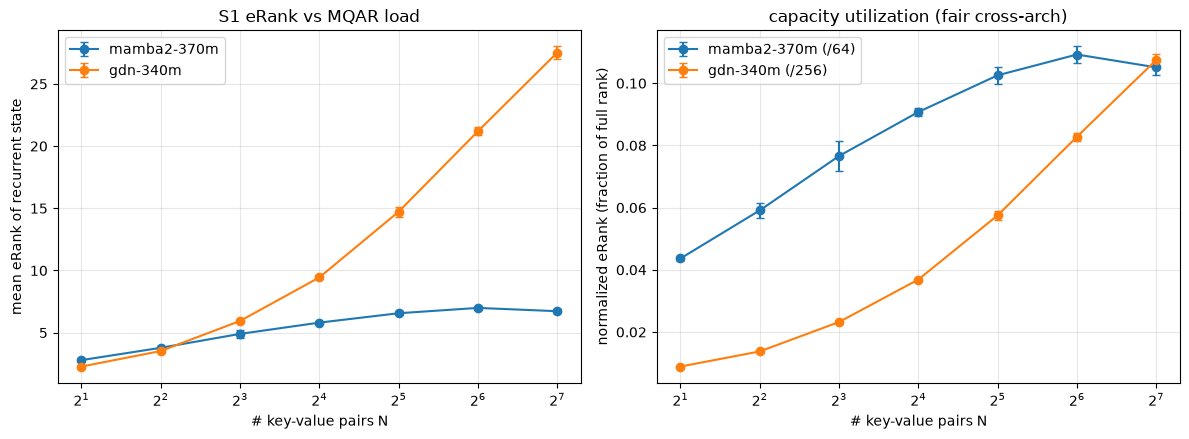

eRank saturation as N grows = capacity signal; the right panel compares the two architectures fairly (normalized).


In [17]:
# 5.3 Compare the two models: raw eRank and normalized eRank vs load
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for _name, rows in sweep.items():
    N  = [r["n_pairs"] for r in rows]
    er = np.array([r["erank_mean"] for r in rows])
    es = np.array([r["erank_std"] for r in rows])
    mr = maxrank[_name]
    ax[0].errorbar(N, er, yerr=es, marker="o", capsize=3, label=_name)
    ax[1].errorbar(N, er / mr, yerr=es / mr, marker="o", capsize=3, label=f"{_name} (/{mr})")
ax[0].set_ylabel("mean eRank of recurrent state"); ax[0].set_title("S1 eRank vs MQAR load")
ax[1].set_ylabel("normalized eRank (fraction of full rank)")
ax[1].set_title("capacity utilization (fair cross-arch)")
for a in ax:
    a.set_xscale("log", base=2); a.set_xlabel("# key-value pairs N"); a.grid(alpha=.3); a.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "worked_example_S1_D1_both.png"), dpi=120)
plt.show()
print("eRank saturation as N grows = capacity signal; the right panel compares the two "
      "architectures fairly (normalized).")

## 6. Full experiment matrix — all signals × all datasets × both models  *(implemented)*

Runs every signal on every dataset for both models and collects the scalars. Each dataset builder has
its own args, so `build_dataset` dispatches (and passes the model's tokenizer to D2). Signals are
averaged over a few sequences. NLL-based signals (S2/S3) are comparable **within a model across
datasets** (the axis we care about), not across models with different tokenizers.

> Note: this cell *runs* the matrix. The deeper question — *does S3 (epiplexity) actually separate
> D1/D2/D3 as predicted (recall ≈ low, natural language / state-tracking higher)?* — is the analysis
> pass in Section 7.

In [18]:
def build_dataset(dname, bundle, **kw):
    if dname == "D1_mqar":
        return make_mqar_batch(**{k: v for k, v in kw.items() if k in ("n_pairs", "vocab", "n_seq")})
    if dname == "D2_natural_language":
        return make_natural_language_batch(bundle.tokenizer,
                                           **{k: v for k, v in kw.items() if k in ("seq_len", "n_seq")})
    if dname == "D3_state_tracking":
        return make_state_tracking_batch(**{k: v for k, v in kw.items() if k in ("task", "length", "n_seq")})
    raise ValueError(dname)

def compute_signals(bundle, ids, meta, n_use=4):
    n = min(n_use, ids.shape[0])
    def avg(fn, key):
        return float(np.mean([fn(bundle, ids[i:i+1])[key] for i in range(n)]))
    return {
        "S1_erank":          avg(S1_erank, "erank_mean"),
        "S2_pred_entropy":   avg(S2_pred_entropy, "pred_entropy_mean"),   # nats
        "S2_bits_per_token": avg(S2_pred_entropy, "bits_per_token"),
        "S3_epiplexity_pt":  avg(S3_epiplexity, "epiplexity_per_token"),  # length-normalized bits
        "S4_gt_bits":        (float(meta["gt_bits"]) if meta.get("gt_bits")
                              else (float(meta["state_bits"]) if meta.get("state_bits") else None)),
    }

# dataset knobs chosen so sequence lengths are broadly comparable across D1/D2/D3
DATASET_SPECS = [
    ("D1_mqar",             dict(n_pairs=64, n_seq=4)),      # T ~ 192
    ("D2_natural_language", dict(seq_len=192, n_seq=4)),
    ("D3_state_tracking",   dict(task="A5", length=192, n_seq=4)),
]

def run_full_matrix(models=("mamba2-370m", "gdn-340m"), specs=DATASET_SPECS):
    results = {}
    for mname in models:
        try:
            b = load_bundle(mname)
        except Exception as e:
            print("skip", mname, "->", type(e).__name__, str(e)[:100]); continue
        results[mname] = {}
        for dname, kw in specs:
            ids, meta = build_dataset(dname, b, **kw)
            row = compute_signals(b, ids, meta)
            results[mname][dname] = row
            print(f"{mname:12s} {dname:20s} " +
                  " ".join(f"{k}={('%.3f'%v) if isinstance(v,float) else v}" for k, v in row.items()))
    with open(os.path.join(RESULTS_DIR, "full_matrix.json"), "w") as f:
        json.dump(results, f, indent=2)
    return results

matrix = run_full_matrix()

mamba2-370m  D1_mqar              S1_erank=6.991 S2_pred_entropy=7.385 S2_bits_per_token=15.274 S3_epiplexity_pt=2.562 S4_gt_bits=576.000


mamba2-370m  D2_natural_language  S1_erank=6.656 S2_pred_entropy=3.154 S2_bits_per_token=4.621 S3_epiplexity_pt=2.158 S4_gt_bits=None


mamba2-370m  D3_state_tracking    S1_erank=6.125 S2_pred_entropy=7.567 S2_bits_per_token=15.381 S3_epiplexity_pt=1.927 S4_gt_bits=5.907


[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type `mom`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[transformers] You are using a model of type `mom_gated_deltanet` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


gdn-340m     D1_mqar              S1_erank=21.192 S2_pred_entropy=7.269 S2_bits_per_token=14.959 S3_epiplexity_pt=1.900 S4_gt_bits=576.000


gdn-340m     D2_natural_language  S1_erank=14.588 S2_pred_entropy=3.034 S2_bits_per_token=4.288 S3_epiplexity_pt=1.740 S4_gt_bits=None


gdn-340m     D3_state_tracking    S1_erank=18.702 S2_pred_entropy=6.846 S2_bits_per_token=15.707 S3_epiplexity_pt=1.666 S4_gt_bits=5.907


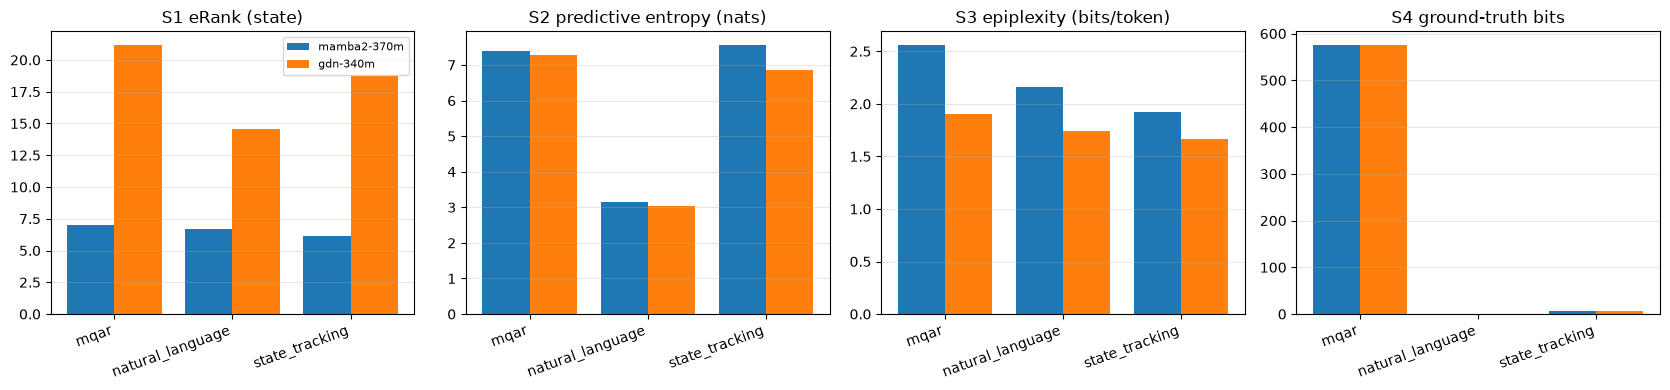

Full signal x dataset x model matrix. S3 per-token is the length-fair epiplexity; watch whether it rises D1(recall) -> D2(NL)/D3(state-tracking) as hypothesized.


In [19]:
# 6.1 Visualize the matrix: one panel per signal, grouped bars over datasets x models
PLOT_SIGNALS = ["S1_erank", "S2_pred_entropy", "S3_epiplexity_pt", "S4_gt_bits"]
TITLES = {"S1_erank": "S1 eRank (state)", "S2_pred_entropy": "S2 predictive entropy (nats)",
          "S3_epiplexity_pt": "S3 epiplexity (bits/token)", "S4_gt_bits": "S4 ground-truth bits"}
models = list(matrix); datasets = [d for d, _ in DATASET_SPECS]
xlab = [d.split("_", 1)[1] for d in datasets]
fig, axes = plt.subplots(1, len(PLOT_SIGNALS), figsize=(4.2 * len(PLOT_SIGNALS), 4))
x = np.arange(len(datasets)); w = 0.8 / max(1, len(models))
for ax, sig in zip(axes, PLOT_SIGNALS):
    for j, m in enumerate(models):
        vals = [matrix[m][d].get(sig) for d in datasets]
        vals = [np.nan if v is None else v for v in vals]
        ax.bar(x + (j - (len(models)-1)/2) * w, vals, w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(xlab, rotation=20, ha="right")
    ax.set_title(TITLES[sig]); ax.grid(alpha=.3, axis="y")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "full_matrix.png"), dpi=120)
plt.show()
print("Full signal x dataset x model matrix. S3 per-token is the length-fair epiplexity; "
      "watch whether it rises D1(recall) -> D2(NL)/D3(state-tracking) as hypothesized.")

## 7. Analysis — which signal best tracks capacity?  **[TODO — next pass]**

Signals and datasets are now all implemented and the matrix (Section 6) runs. The analysis pass:
1. **S3-by-dataset (priority).** Test the hypothesis that epiplexity separates the regimes:
   D1 MQAR (random k-v → little learnable structure → low S3) vs D2 natural language and
   D3 state-tracking (strong structure → higher S3). Run multiple seeds, report means ± CI and an
   effect size per dataset pair; control for sequence length (use `epiplexity_per_token`).
2. **Calibration on D1 (MQAR).** Sweep N and correlate each signal with `gt_bits = N·log2|V|`
   (Spearman ρ). The signal tracking ground-truth capacity best wins calibration. (S1 sweep already
   done in Section 5 — extend to S2/S3/S4.)
3. **S4 probe.** Fit a linear probe from the recurrent state to the stored value (MQAR) / running
   state (D3 `state_seq`) → *decodable* bits; compare to ground truth.
4. **Architecture check.** Does the best signal agree across mamba2-370m vs MoM Gated-DeltaNet, or is
   it architecture-specific? (Section 5 already shows their eRank scaling differs markedly.)
5. **Deliverable.** A `signal × dataset` summary + a ranking of signals by (calibration ρ ×
   cross-dataset discriminability), naming the single best "information-capacity" signal.
